<a href="https://colab.research.google.com/github/nikolasluis/Aprendizado-de-M-quina-Supervisionado---Equipe-8/blob/main/Trabalho_Pr%C3%A1tico_%E2%80%94_Compara%C3%A7%C3%A3o_de_Algoritmos_de_Aprendizado_de_M%C3%A1quina_Supervisionado_Equipe_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático — Comparação de Algoritmos de Aprendizado de Máquina Supervisionado



##Objetivo

Aplicar os conceitos de aprendizado supervisionado abordados em aula: i) KNN, ii) SVM, iii) Árvores de Decisão e iv) MLP na resolução de um problema real de **Classificação** ou **Regressão**. O trabalho tem como foco a análise comparativa de desempenho entre algoritmos, bem como a discussão crítica dos resultados obtidos.

⚠️

O notebook entregue deve ser autocontido e totalmente executável. Isso significa que:

* Todas as bibliotecas necessárias devem ser importadas explicitamente no início do notebook.

* Exceto pelo carregamento (upload) do dataset (i.e data.zip), o restante código deve ser executável do início ao fim sem intervenções manuais, sem necessidade de ajustes, inserção de inputs, descompactações e/ou modificações de caminho de arquivos.

* Todos os arquivos necessários (por exemplo, dataset processado) devem estar acessíveis via link público para download.

* O notebook deve gerar todas as saídas esperadas automaticamente, incluindo métricas, gráficos e relatórios, sem dependência de ações externas.


⚠️ Exceto pelo carregamento do dataset (i.e data.zip), trabalhos que exigirem intervenção manual (como importação adicional de bibliotecas, inserção de inputs ou correções de código) serão desconsiderados na avaliação.



##Identificação da Equipe:

* **ID GRUPO CANVAS**:
* **Membro 1**:
* **Membro 2**:
* **Membro 3**:
* **Membro 4**:
* **Membro 5**:


⚠️ Além da identificação, **todos os membros do grupo** devem estar devidamente alocados no ambiente virtual (AVA), em:
**Pessoas → Grupos → Trabalho Final.**

⚠️ Apenas **uma submissão por grupo** é necessária. Entretanto, é imprescindível que **todos os integrantes estejam alocados** no respectivo grupo para que a atribuição do envio seja registrada corretamente.


##Seed

In [ ]:
# Imports iniciais
import os
import random
import sklearn
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC as SVM
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definição de semente para reprodutibilidade
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

#Definição e Descrição do Dataset

### Seleção do Dataset

Selecione um **dataset público** disponível no [Kaggle – Categoria Classification](https://www.kaggle.com/datasets?tags=13302-Classification), que contenha **rótulos (labels)**, caracterizando uma tarefa de **classificação binária** ou **multiclasse**.

O dataset escolhido deve apresentar **quantidade suficiente de instâncias e atributos** para permitir uma análise estatística e experimental significativa.

Caso o dataset tenha sido **pré-processado** (por exemplo: limpeza, seleção de atributos, codificação ou balanceamento), o **arquivo resultante** deve ser compartilhado em um link público (Google Drive, Dropbox, etc.), de modo que possa ser baixado e executado sem restrições.

> 🔗 **LINK PARA O DATASET:**
> *(Insira aqui o link direto para o dataset original ou processado)* <<==

⚠️ **Observação:** Trabalhos sem o link de acesso ao dataset não serão avaliados, pois impedem a reprodutibilidade do experimento.



---



##Descreva sucitamente o dataset (aplicação, desafios, etc)



---

#Preparação dos Dados

Nesta seção, desenvolva **rotinas** para o tratamento do dataset selecionado, contemplando as seguintes etapas:

* **Descompactação e Importação:** implemente a leitura direta do arquivo (CSV, XLSX, ZIP, etc.), garantindo o correto carregamento dos dados.
* **Limpeza e Pré-processamento:** realize as etapas necessárias de tratamento, como remoção de valores ausentes, codificação de variáveis categóricas, normalização ou padronização, e balanceamento das classes, quando aplicável.
* **Divisão dos Conjuntos:** separe o dataset em **treino, validação e teste**, utilizando o método **Holdout** de forma adequada à natureza do problema.
* **Análise Exploratória:** elabore **gráficos e estatísticas descritivas** que permitam compreender a distribuição das variáveis, a correlação entre atributos e o equilíbrio entre as classes.

**Descompactação e Importação**

In [ ]:
file_path = 'heart.csv'

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  'fedesoriano/heart-failure-prediction',
  file_path
)

/tmp/ipykernel_3993/3479902626.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


**Limpeza e Pré-Processamento**

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

col_qualitativas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
col_quantitativas =  ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']

preprocessador = ColumnTransformer([
    ('quantitativas', StandardScaler(), col_quantitativas),
    ('qualitativas', OneHotEncoder(drop='first'), col_qualitativas)
])

**Divisão dos conjuntos**

In [ ]:
test_size = 0.2
random_state = SEED

x_train, x_test, y_train, y_test, = train_test_split(x, y, test_size=test_size, random_state=random_state)
x_train, x_val, y_train, y_val, = train_test_split(x_train, y_train, test_size=test_size, random_state=random_state)

print(f"Treino: {len(x_train)} | Validação: {len(x_val)} | Teste: {len(x_test)}")

Treino: 587 | Validação: 147 | Teste: 184


**Anánlise Exploratória**

*Correlação entre variavéis numéricas*

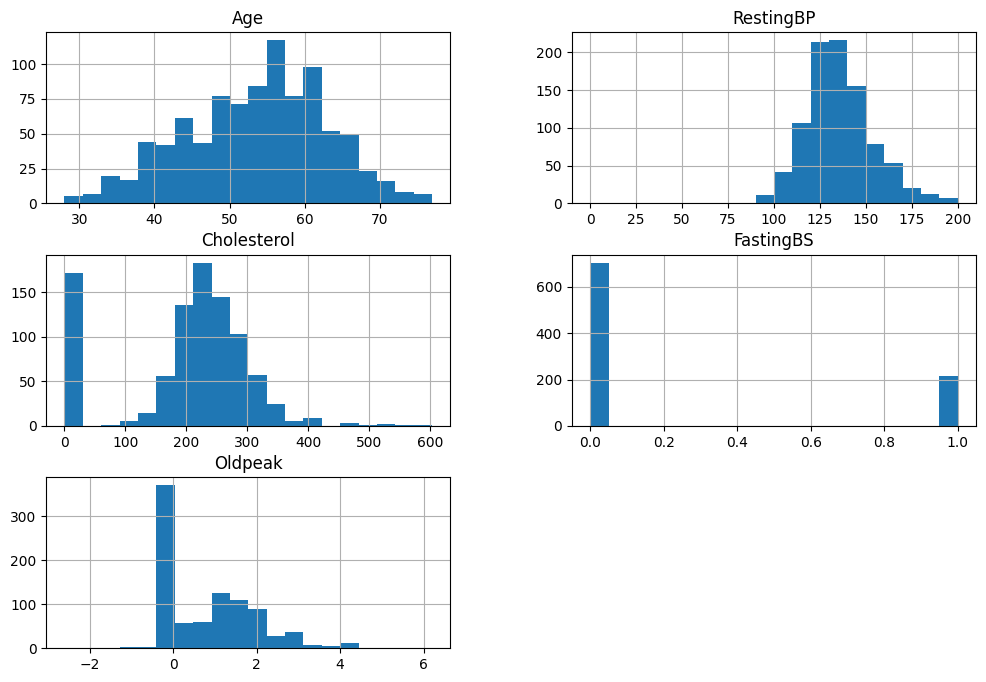

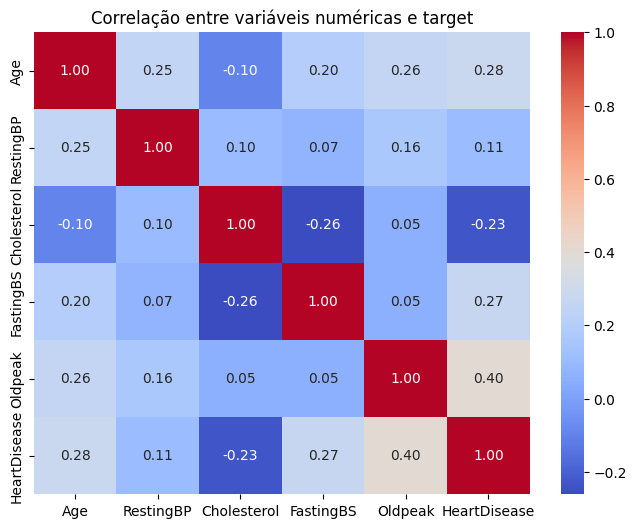

In [ ]:
df[col_quantitativas].hist(bins=20, figsize=(12,8))

plt.figure(figsize=(8,6))
sns.heatmap(df[col_quantitativas + ['HeartDisease']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas e target')
plt.show()

*Distribuição de classes (equilíbrio entre as classes)*

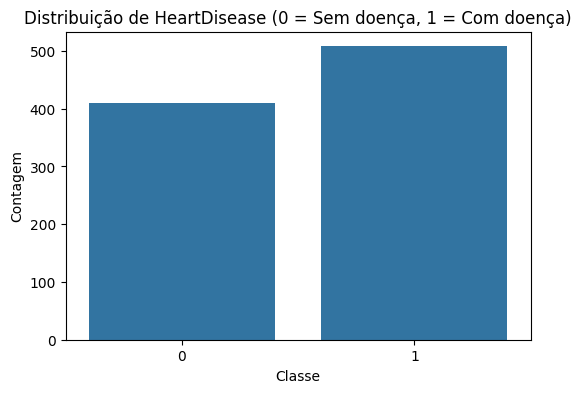

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribuição de HeartDisease (0 = Sem doença, 1 = Com doença)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

# Proporções
print(df['HeartDisease'].value_counts(normalize=True))

---

#Implementação dos Modelos

Treinar e testar os seguintes algoritmos:

* K-Nearest Neighbors (KNN)

* Support Vector Machine (SVM)

* Decision Tree (Árvore de Decisão)

* Multi-Layer Perceptron (MLP)


**Implementação do modelo**

*Modelo RBF*

In [ ]:
modelo_rbf = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='rbf'))
])
modelo_rbf.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quantitativas',
                                                  StandardScaler(),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak', 'FastingBS']),
                                                 ('qualitativas',
                                                  OneHotEncoder(drop='first'),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('svm', SVC())])

*Modelo Linear*

In [ ]:
modelo_linear = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='linear'))
])
modelo_linear.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quantitativas',
                                                  StandardScaler(),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak', 'FastingBS']),
                                                 ('qualitativas',
                                                  OneHotEncoder(drop='first'),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('svm', SVC(kernel='linear'))])

*Modelo Polinomial*

In [ ]:
modelo_poly = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='poly'))
])
modelo_poly.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quantitativas',
                                                  StandardScaler(),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak', 'FastingBS']),
                                                 ('qualitativas',
                                                  OneHotEncoder(drop='first'),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('svm', SVC(kernel='poly'))])

---

#Avaliação dos modelos


* Calcular e comparar as métricas: Acurácia, Precisão, Recall e F1-Score.


* Plotar e comentar as matrizes de confusão.


* Discutir o impacto dos hiperparâmetros e preprocessamentos aplicados.

Aqui você pode elaborar gráficos, analises de resultados da maneira que desejar. No entanto, espera-se uma breve discussão dos resultados e análises críticas.


*Modelo RBF*

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        77
           1       0.88      0.88      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



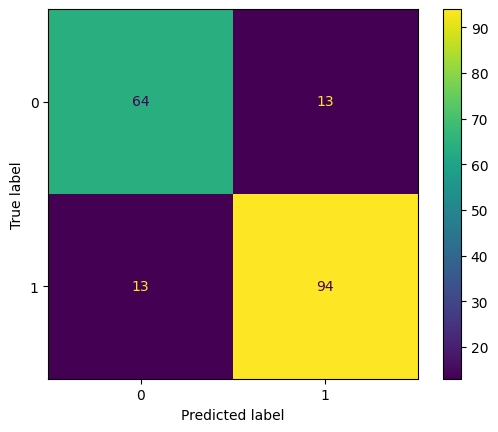

In [ ]:
y_pred = modelo_rbf.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=modelo_rbf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=modelo_rbf.classes_)
disp.plot()

plt.show()

---

# Discussão, análise crítica e conclusão


* Apresentar e discutir o modelo de melhor desempenho e justificar tecnicamente

* Apresentar e discutir as limitações e possíveis desafios.


---

#Submissão

O notebook desenvolvido no Google Colab deve ser exportado em formato PDF por meio da opção:
Arquivo → Imprimir → Salvar como PDF.

É obrigatório que o arquivo PDF contenha todas as células processadas, exibindo os resultados, gráficos e métricas gerados durante a execução. Trabalhos submetidos com células não executadas ou sem resultados visíveis não serão avaliados.

A submissão deve seguir as seguintes orientações:

O envio deve ser feito por apenas um integrante do grupo, previamente cadastrado no AVA.

O notebook Colab original deve estar compartilhado publicamente (ou com permissão de visualização) e o link de acesso deve ser inserido abaixo:

🔗 LINK PARA O COLAB:
(Insira aqui o link de compartilhamento do notebook no Google Colab)

Essa etapa permite ao professor a verificação do código-fonte completo, dos procedimentos de análise e da reprodutibilidade dos resultados.


BOM TRABALHO!! ✅ !!!

---
